In [8]:
import numpy as np
import numpy.linalg as npl

def steepestDescBckTrck(x0, f, gradf, alpha0, kmax, tolgrad, c1, rho, btmax):
    xk = 0
    k = 0
    xk = x0.copy()
    
    # store the sequence of iterates
    xseq = [xk.copy()]

    
    gradfk_norm = npl.norm(gradf(xk))
    while k < kmax and gradfk_norm > tolgrad:
        pk = - gradf(xk)
        alpha_k = getAlpha(f, gradf, xk, pk, alpha0, rho, c1, btmax)
        xk = xk + alpha_k * pk
        gradfk_norm = npl.norm(gradf(xk))
        fk = f(xk)
        k = k + 1
        xseq.append(xk.copy())
    
    # convert list to a matrix with columns as iterations
    xseq = np.column_stack(xseq)
    return xk, fk, gradfk_norm, k, xseq

    
def getAlpha(f, grad_f, x, p, alpha0=1.0, rho=0.5, c=1e-4, btmax=20):
    k = 0
    satisfyed = False
    fx = f(x)
    grad_fx = grad_f(x)
    
    while k < btmax and not satisfyed:
        alpha = alpha0 * (rho ** k)
        if f(x + alpha * p) <= fx + c * alpha * np.dot(grad_fx, p):
            satisfyed = True
        else:
            k += 1
    
    return alpha if satisfyed else alpha0 * (rho ** btmax)


In [22]:
# ------------------------
# TEST FUNCTION
# ------------------------

# Quadratic bowl: minimum at (2, -1)
f = lambda x: (x[0] - 2)**2 + (x[1] + 1)**2
gradf = lambda x: np.array([2*(x[0] - 2), 2*(x[1] + 1)])

def f_rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    return np.array([
        -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2),
        200*(x[1] - x[0]**2)
    ])

# Starting point
x0 = np.array([5.0, 5.0])

# Parameters
alpha0 = 1.0
kmax = 100
tolgrad = 1e-6
c1 = 1e-4
rho = 0.5
btmax = 20

# Run algorithm
xk, fk, grad_norm, k, xseq = steepestDescBckTrck(x0, f, gradf, alpha0, kmax, tolgrad, c1, rho, btmax)

# ------------------------
# RESULTS
# ------------------------
print("Final point xk =", xk)
print("Function value f(xk) =", fk)
print("Gradient norm =", grad_norm)
print("Iterations =", k)
print("Expected minimum = [2, -1]")

x0 = np.array([-1.5, 1.5])   # far from the minimum

xk, fk, grad_norm, k, xseq = steepestDescBckTrck(
    x0, f_rosenbrock, grad_rosenbrock,
    alpha0=1.0, kmax=10000, tolgrad=1e-14,
    c1=1e-4, rho=0.5, btmax=20
)

print("Final xk =", xk)
print("f(xk) =", fk)
print("grad_norm =", grad_norm)
print("Iterations =", k)


Final point xk = [ 2. -1.]
Function value f(xk) = 0.0
Gradient norm = 0.0
Iterations = 1
Expected minimum = [2, -1]
Final xk = [0.99996288 0.99992549]
f(xk) = 1.385285092074964e-09
grad_norm = 6.675076983727234e-05
Iterations = 10000


Final xk = [0.99996288 0.99992549]
f(xk) = 1.385285092074964e-09
Iterations = 10000


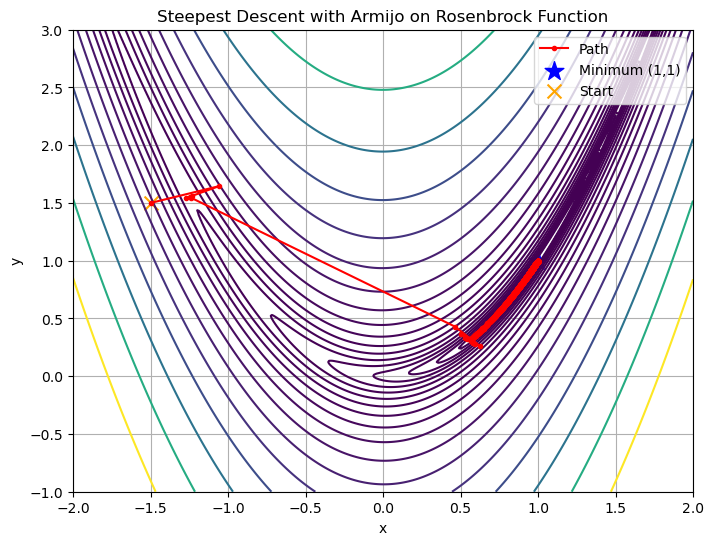

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Rosenbrock function and gradient
# ------------------------------------
def f_rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    return np.array([
        -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2),
        200*(x[1] - x[0]**2)
    ])

# ------------------------------------
# Run the steepest descent with Armijo
# ------------------------------------
x0 = np.array([-1.5, 1.5])

xk, fk, grad_norm, k, xseq = steepestDescBckTrck(
    x0, f_rosenbrock, grad_rosenbrock,
    alpha0=1.0, kmax=10000, tolgrad=1e-8,
    c1=1e-4, rho=0.5, btmax=20
)

print("Final xk =", xk)
print("f(xk) =", fk)
print("Iterations =", k)

# ------------------------------------
# Plot the contour and trajectory
# ------------------------------------
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap="viridis")

# Path of iterations
plt.plot(xseq[0,:], xseq[1,:], 'o-', color='red', markersize=3, label="Path")
plt.scatter([1], [1], color='blue', marker='*', s=200, label="Minimum (1,1)")
plt.scatter(x0[0], x0[1], color='orange', marker='x', s=100, label="Start")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Steepest Descent with Armijo on Rosenbrock Function")
plt.legend()
plt.grid(True)
plt.show()
